<a href="https://colab.research.google.com/github/123Erina/UTS_VISIKOMPUTER_23423018/blob/main/Copy_of_Segmentasi_MataKatarak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving mata.jpg to mata.jpg


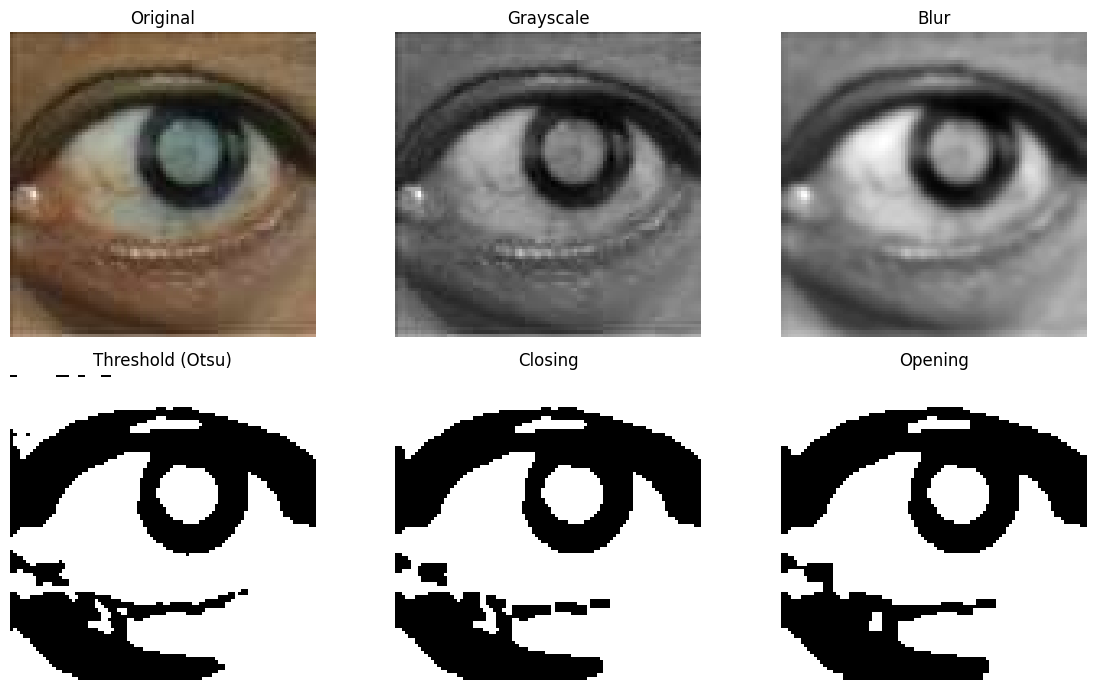

In [1]:
# install library
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================
# 1. UPLOAD GAMBAR
# =====================
uploaded = files.upload()

# baca gambar
img = cv2.imread(list(uploaded.keys())[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =====================
# 2. GRAYSCALE
# =====================
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# =====================
# 3. BLUR (biar halus)
# =====================
blur = cv2.GaussianBlur(gray, (5,5), 0)

# =====================
# 4. THRESHOLD (OTSU - otomatis)
# =====================
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# =====================
# 5. MORFOLOGI
# =====================
kernel = np.ones((3,3), np.uint8)

# closing → menutup lubang kecil
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# opening → menghilangkan noise kecil
opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel)

# =====================
# 6. TAMPILKAN HASIL
# =====================
titles = [
    'Original',
    'Grayscale',
    'Blur',
    'Threshold (Otsu)',
    'Closing',
    'Opening'
]

images = [img, gray, blur, thresh, closing, opening]

plt.figure(figsize=(12,7))
for i in range(len(images)):
    plt.subplot(2,3,i+1)
    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()